In [48]:
import yfinance as yf 
import numpy as np 
import pandas as pd
from scipy.stats import norm
from datetime import datetime,timedelta
import matplotlib.pyplot as plt

In [49]:
years = 15
end_date= datetime.today()
start_date= end_date - timedelta(days=365*15)

In [61]:
tickers = ["QQQ","VTI","GLD","BND","SPY"]
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker,start=start_date,end=end_date,auto_adjust=True)
    adj_close_df[ticker] =data["Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [62]:
log_returns= np.log(adj_close_df/adj_close_df.shift(1))

In [63]:
log_returns= log_returns.dropna()

In [64]:
log_returns

,QQQ,VTI,GLD,BND,SPY
Date,,,,,
2011-08-09,0.047103,0.048832,0.008876,0.003486,0.045450
2011-08-10,-0.041781,-0.043441,0.034795,0.007887,-0.045183
2011-08-11,0.043100,0.044768,-0.022183,-0.009689,0.043906
2011-08-12,0.008812,0.006612,-0.004579,0.003240,0.006710
2011-08-15,0.014639,0.021513,0.010709,-0.001678,0.020944
...,...,...,...,...,...
2026-07-28,-0.009767,0.002216,-0.014140,0.002481,0.002392
2026-07-29,-0.020581,-0.015336,0.004619,-0.003586,-0.015507
2026-07-30,0.032442,0.016101,0.016252,0.000553,0.016627


In [65]:
###expected return

def expected_return (weights,log_returns):
    return np.sum(log_returns.mean() *weights)
    

In [29]:
###covariance 
cov_matrix= log_returns.cov()
cov_matrix

,QQQ,VTI,GLD,BND,SPY
QQQ,0.000173,0.000134,0.000011,0.000003,0.000132
VTI,0.000134,0.000121,0.000009,0.000002,0.000118
GLD,0.000011,0.000009,0.000112,0.000010,0.000008
BND,0.000003,0.000002,0.000010,0.000010,0.000002
SPY,0.000132,0.000118,0.000008,0.000002,0.000116


In [30]:
correlation = log_returns.corr()
correlation

,QQQ,VTI,GLD,BND,SPY
QQQ,1.000000,0.925875,0.078548,0.068112,0.930145
VTI,0.925875,1.000000,0.073297,0.062335,0.996060
GLD,0.078548,0.073297,1.000000,0.291551,0.069166
BND,0.068112,0.062335,0.291551,1.000000,0.056532
SPY,0.930145,0.996060,0.069166,0.056532,1.000000


In [31]:
##standard dev
def standard_deviation(weights,cov_matrix):
    variance = weights.T@cov_matrix@weights
    return np.sqrt(variance)

In [32]:
portfolio_value=1000000
weights= np.array([1/len(tickers)]*len(tickers))
portfolio_expected_return = expected_return(weights,log_returns)
portfolio_standard_deviation = standard_deviation(weights,cov_matrix)

In [33]:
portfolio_standard_deviation

np.float64(0.007443853174394624)

In [34]:
weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [35]:
days = 5 
def scenario_gain_loss (portfolio_value,portfolio_standard_deviation,z_score,days):
    return portfolio_value*portfolio_expected_return*days + portfolio_value*portfolio_standard_deviation*z_score*np.sqrt(days)
   

In [36]:
## Z score fuction

def random_z_score():
    return np.random.normal(0,1)

In [37]:
##number of simulations

simulations = 10000
scenarioReturn =[]
for i in range (simulations):
    z_score = random_z_score()
    scenarioReturn.append(scenario_gain_loss(portfolio_value,portfolio_standard_deviation,z_score,days))

In [38]:
scenario_gain_loss(portfolio_value,portfolio_standard_deviation,z_score,days)

np.float64(15674.172810225944)

In [39]:
portfolio_standard_deviation

np.float64(0.007443853174394624)

In [40]:
###confidence interval

confidence_interval = 0.99
vAR= -np.percentile(scenarioReturn,100*(1-confidence_interval))
print(vAR)

36620.865383767385


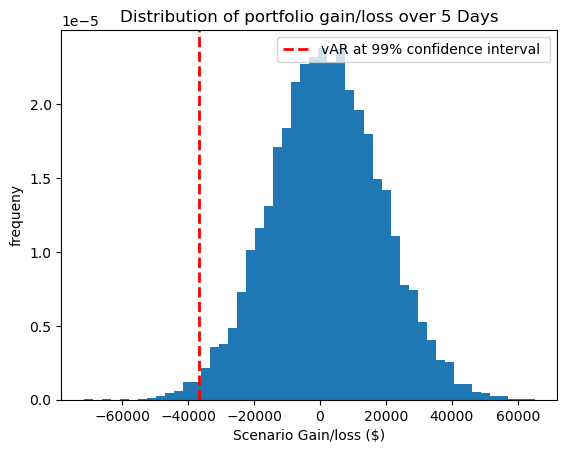

In [41]:
###plot of var

plt.hist(scenarioReturn,bins=50,density=True)
plt.xlabel("Scenario Gain/loss ($)")
plt.ylabel("frequeny")
plt.title(f"Distribution of portfolio gain/loss over {days} Days")
plt.axvline(-vAR,color="r",linestyle="dashed",linewidth=2,label=f"vAR at {confidence_interval:.0%} confidence interval ")
plt.legend()
plt.show()